<h1 style="color:#56B4E9;">Week 6 — Day 2</h1>

<h2 style="color:#0072B2;">Activation Functions, Forward Propagation, and Loss</h2>

### ECG-Based Multi-Label Cardiac Diagnosis Using PTB-XL

During Day 1, the PTB-XL data was prepared and the diagnostic task was defined. Day 2 focuses on the internal calculations that allow a neural network to transform an input into four independent disease probabilities.

The current target order is:

`[MI, STTC, CD, HYP]`

One ECG may contain more than one disease, so this is a multi-label classification task.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Explain why non-linear activation functions are necessary.
- Compare ReLU, sigmoid, and tanh.
- Select the correct hidden-layer and output-layer activations.
- Perform a complete forward pass using NumPy.
- Explain why Binary Cross-Entropy is appropriate for this project.
- Compare the loss of good, uncertain, and incorrect predictions.

<h2 style="color:#0072B2;">1. Activation Functions</h2>

A neuron first calculates a weighted sum:

$$
z = XW + b
$$

Without an activation function, every layer performs only a linear transformation. Multiple linear layers can therefore be combined into a single linear transformation.

<span style="color:#D55E00;"><b>Problem:</b></span>  
A completely linear network cannot learn complex non-linear relationships in ECG signals.

<span style="color:#009E73;"><b>Solution:</b></span>  
Apply a non-linear activation function after the weighted sum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def relu(z):
    return np.maximum(0, z)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def tanh(z):
    return np.tanh(z)

In [2]:
z_values = np.linspace(-6, 6, 500)

relu_values = relu(z_values)
sigmoid_values = sigmoid(z_values)
tanh_values = tanh(z_values)

print("Input range:")
print(z_values.min(), "to", z_values.max())

print("\nOutput ranges:")
print("ReLU:", round(relu_values.min(), 3), "to", round(relu_values.max(), 3))
print("Sigmoid:", round(sigmoid_values.min(), 3), "to", round(sigmoid_values.max(), 3))
print("Tanh:", round(tanh_values.min(), 3), "to", round(tanh_values.max(), 3))

Input range:
-6.0 to 6.0

Output ranges:
ReLU: 0.0 to 6.0
Sigmoid: 0.002 to 0.998
Tanh: -1.0 to 1.0


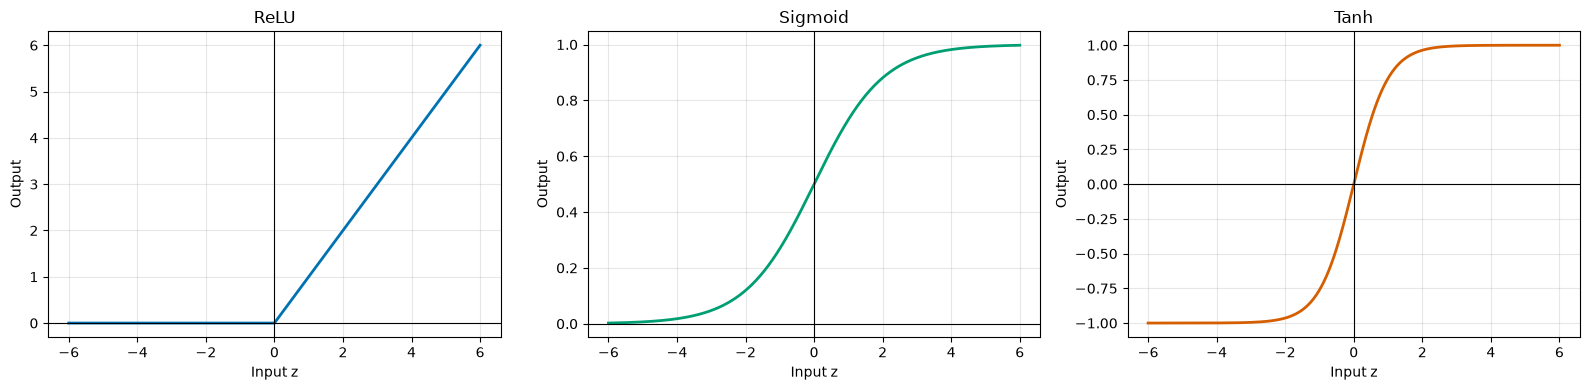

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plots = [
    (relu_values, "ReLU", "#0072B2"),
    (sigmoid_values, "Sigmoid", "#009E73"),
    (tanh_values, "Tanh", "#D55E00"),
]

for axis, (values, title, color) in zip(axes, plots):
    axis.plot(z_values, values, color=color, linewidth=2)
    axis.set_title(title)
    axis.set_xlabel("Input z")
    axis.set_ylabel("Output")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Activation Function Results</h3>

- ReLU converted negative inputs to zero and preserved positive inputs. Its theoretical range is $[0,+\infty)$.
- Sigmoid compressed all inputs into values between zero and one, making it suitable for probabilities.
- Tanh produced zero-centered outputs between negative one and positive one.

<span style="color:#D55E00;"><b>Observation:</b></span>  
Sigmoid and tanh became almost flat at large positive and negative inputs. This is called saturation and can produce very small gradients.

<span style="color:#009E73;"><b>Project Decision:</b></span>

- Use ReLU in the hidden layers.
- Use four independent sigmoid units in the output layer.
- Do not use softmax because more than one disease may be present.

<h2 style="color:#0072B2;">2. Forward Propagation</h2>

Forward propagation moves an input through the network to produce a prediction:

$$
Z_1 = XW_1 + b_1
$$

$$
A_1 = ReLU(Z_1)
$$

$$
Z_2 = A_1W_2 + b_2
$$

$$
\hat{Y} = Sigmoid(Z_2)
$$

During this step, the network only calculates a prediction. It does not update the weights or biases.

<h3 style="color:#009E73;">Creating a Small Traceable Network</h3>

The example uses one input sample, two input features, two hidden neurons, and four output neurons. Small values are used so every NumPy calculation can be verified manually.

In [4]:
X = np.array([[2.0, 1.0]])

W1 = np.array([
    [0.5, -1.0],
    [1.0,  0.5]
])
b1 = np.array([0.0, 1.0])

W2 = np.array([
    [1.0, 0.5, -1.0,  0.0],
    [0.5, 1.0,  0.5, -1.0]
])
b2 = np.array([-1.0, 0.0, 1.0, -0.5])

print("X shape:", X.shape)
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

X shape: (1, 2)
W1 shape: (2, 2)
b1 shape: (2,)
W2 shape: (2, 4)
b2 shape: (4,)


In [5]:
Z1 = X @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
Y_hat = sigmoid(Z2)

print("Z1 before ReLU:")
print(Z1)
print("\nA1 after ReLU:")
print(A1)
print("\nZ2 before Sigmoid:")
print(Z2)
print("\nPredicted probabilities:")
print(np.round(Y_hat, 3))

Z1 before ReLU:
[[ 2.  -0.5]]

A1 after ReLU:
[[2. 0.]]

Z2 before Sigmoid:
[[ 1.   1.  -1.  -0.5]]

Predicted probabilities:
[[0.731 0.731 0.269 0.378]]


<h3 style="color:#009E73;">Forward Propagation Results</h3>

The first matrix multiplication was:

$$
(1,2)\times(2,2)=(1,2)
$$

The hidden-layer values were $Z_1=[2,-0.5]$. After ReLU, $A_1=[2,0]$.

The second matrix multiplication was:

$$
(1,2)\times(2,4)=(1,4)
$$

The output-layer values were $Z_2=[1,1,-1,-0.5]$. After applying sigmoid independently:

$$
\hat{Y}=[0.731,0.731,0.269,0.378]
$$

<span style="color:#D55E00;"><b>Important:</b></span>  
These probabilities are illustrative. The weights and biases were manually selected and have not been learned from ECG data.

In [6]:
target_classes = ["MI", "STTC", "CD", "HYP"]
threshold = 0.5
binary_prediction = (Y_hat >= threshold).astype(int)

print("Threshold:", threshold)
print("\nMulti-label prediction:")

for disease, probability, prediction in zip(
    target_classes,
    Y_hat[0],
    binary_prediction[0]
):
    print(f"{disease:4s}: probability={probability:.3f}, prediction={prediction}")

Threshold: 0.5

Multi-label prediction:
MI  : probability=0.731, prediction=1
STTC: probability=0.731, prediction=1
CD  : probability=0.269, prediction=0
HYP : probability=0.378, prediction=0


<h3 style="color:#009E73;">Threshold Interpretation</h3>

Using a provisional threshold of `0.5`, the example predicts both `MI` and `STTC` as present. This demonstrates why sigmoid fits multi-label classification: several outputs can be positive simultaneously.

The final project threshold should not be selected arbitrarily. It will later be tuned on validation data, with special attention to Recall because missing a disease is clinically costly.

<h2 style="color:#0072B2;">3. Selecting the Loss Function</h2>

The loss function measures how different the predicted probabilities are from the true labels.

| Task | Output activation | Typical loss |
|---|---|---|
| Regression | Linear | Mean Squared Error |
| Binary classification | Sigmoid | Binary Cross-Entropy |
| Multi-class classification | Softmax | Categorical Cross-Entropy |
| Multi-label classification | Independent sigmoid units | Binary Cross-Entropy |

Our task contains four independent binary decisions. Therefore, Binary Cross-Entropy is calculated independently for each disease and then averaged.

<h3 style="color:#009E73;">Binary Cross-Entropy</h3>

For one binary label:

$$
BCE(y,\hat{y})=-[y\log(\hat{y})+(1-y)\log(1-\hat{y})]
$$

If the true label is `1`, the first term evaluates the predicted probability of presence. If the true label is `0`, the second term evaluates the predicted probability of absence.

Confident incorrect predictions receive a much larger penalty than uncertain predictions.

In [7]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    label_losses = -(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

    return label_losses, np.mean(label_losses)


y_true = np.array([[1, 1, 0, 0]])
label_losses, mean_loss = binary_cross_entropy(y_true, Y_hat)

print("True labels:", y_true)
print("Predicted probabilities:", np.round(Y_hat, 3))
print("Loss per disease:", np.round(label_losses, 3))
print("Mean Binary Cross-Entropy:", round(mean_loss, 3))

True labels: [[1 1 0 0]]
Predicted probabilities: [[0.731 0.731 0.269 0.378]]
Loss per disease: [[0.313 0.313 0.313 0.474]]
Mean Binary Cross-Entropy: 0.353


<h3 style="color:#009E73;">Why Average the Four Losses?</h3>

Each output represents a separate binary problem. The network first calculates one loss for each disease, then averages them to produce a single value for the sample.

That single value summarizes the current prediction error and will later guide weight updates during backpropagation.

In [8]:
good_prediction = np.array([[0.95, 0.90, 0.05, 0.10]])
uncertain_prediction = np.array([[0.55, 0.55, 0.45, 0.45]])
bad_prediction = np.array([[0.05, 0.10, 0.95, 0.90]])

prediction_sets = {
    "Good": good_prediction,
    "Uncertain": uncertain_prediction,
    "Bad": bad_prediction,
}

comparison_losses = {}

for name, prediction in prediction_sets.items():
    _, loss = binary_cross_entropy(y_true, prediction)
    comparison_losses[name] = loss
    print(f"{name:9s} prediction loss: {loss:.3f}")

Good      prediction loss: 0.078
Uncertain prediction loss: 0.598
Bad       prediction loss: 2.649


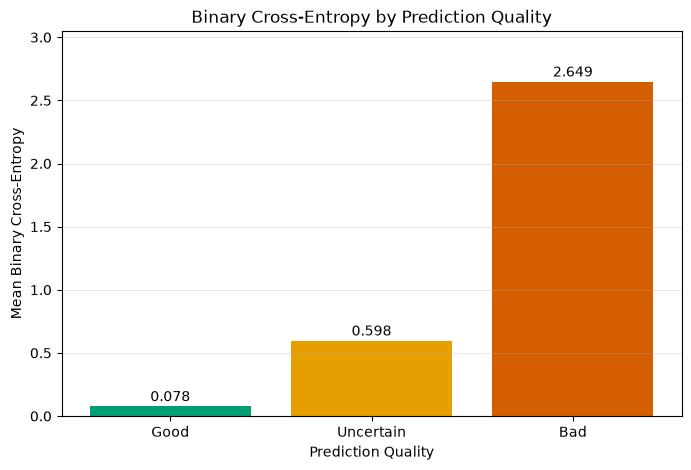

In [9]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_losses.keys(),
    comparison_losses.values(),
    color=["#009E73", "#E69F00", "#D55E00"]
)

plt.title("Binary Cross-Entropy by Prediction Quality")
plt.xlabel("Prediction Quality")
plt.ylabel("Mean Binary Cross-Entropy")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.ylim(0, max(comparison_losses.values()) + 0.4)
plt.show()

<h3 style="color:#009E73;">Loss Comparison Results</h3>

- The good prediction produced the smallest loss because its probabilities were close to the true labels.
- The uncertain prediction produced an intermediate loss.
- The confidently incorrect prediction produced the largest loss.

<span style="color:#009E73;"><b>Main Principle:</b></span>  
Training attempts to change the weights and biases so that the average loss becomes smaller over repeated examples.

<h2 style="color:#0072B2;">4. Final Project Decisions</h2>

The Day 2 experiments support the following neural-network configuration:

- **Hidden activation:** ReLU
- **Output size:** Four neurons
- **Output activation:** Independent sigmoid
- **Loss function:** Binary Cross-Entropy
- **Target order:** `[MI, STTC, CD, HYP]`
- **Primary evaluation focus:** Recall, while also reporting Macro F1 and per-class metrics

The threshold used today was `0.5` only for demonstration. It will later be tuned using validation data.

<h2 style="color:#0072B2;">5. Day 2 Conclusion</h2>

Day 2 established how a neural network converts an input into multi-label disease probabilities.

ReLU introduced non-linearity in the hidden layer. Forward propagation combined inputs, weights, biases, and activations to produce four independent sigmoid probabilities. Binary Cross-Entropy then measured the difference between those probabilities and the true disease labels.

The experiments showed that good predictions produce a small loss, uncertain predictions produce a moderate loss, and confidently incorrect predictions receive a large penalty.

<span style="color:#009E73;"><b>What Was Learned:</b></span>

- Why hidden layers need non-linear activation functions.
- How matrix dimensions determine network connections.
- How forward propagation produces predictions.
- Why sigmoid is appropriate for multi-label outputs.
- Why Binary Cross-Entropy is the correct loss for this project.

<span style="color:#D55E00;"><b>Next Step:</b></span>  
Day 3 will explain gradients, backpropagation, learning rates, and optimization with Adam and SGD.